In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Configurações de visualização
%matplotlib inline
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', None) # Mostrar todas as colunas

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Recarregando os dados para garantir a integridade
data_path = '../../data/processed'

df_train = pd.read_csv(os.path.join(data_path, 'ubuntu_server_dataset_train.csv'))
df_test = pd.read_csv(os.path.join(data_path, 'ubuntu_server_dataset_test.csv'))

# Removendo a coluna 'id' que não é uma feature
df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)

# A feature 'service' tem alguns valores '-' que precisam ser tratados. Vamos mantê-los como uma categoria.
df_train['service'] = df_train['service'].replace('-', 'unknown')
df_test['service'] = df_test['service'].replace('-', 'unknown')

# Definindo X (features) e y (alvo)
# Nosso alvo agora é 'attack_cat' para a classificação multiclasse
X_train = df_train.drop(['attack_cat', 'label', 'ct_ftp_cmd'], axis=1)
y_train = df_train['attack_cat']

X_test = df_test.drop(['attack_cat', 'label', 'ct_ftp_cmd'], axis=1)
y_test = df_test['attack_cat']

# Identificando colunas numéricas e categóricas
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

# Criando o pré-processador com ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Mantém colunas não especificadas (se houver)
)

# Criando o pipeline final que inclui o pré-processamento e o classificador
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'))
])

print("Pipeline de pré-processamento e modelo criado com sucesso.")
print(f"Features numéricas ({len(numeric_features)}): {numeric_features.tolist()}")
print(f"Features categóricas ({len(categorical_features)}): {categorical_features.tolist()}")

Pipeline de pré-processamento e modelo criado com sucesso.
Features numéricas (38): ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']
Features categóricas (3): ['proto', 'service', 'state']


In [3]:
print("Iniciando o treinamento do modelo Random Forest...")

# Treinando o pipeline no conjunto de dados de treino
model_pipeline.fit(X_train, y_train)

try:
    # Define o nome do arquivo para salvar o pipeline treinado
    pipeline_filename = 'pipeline_RF.joblib'
    joblib.dump(model_pipeline, pipeline_filename)
    print(f"Pipeline treinado salvo com sucesso como '{pipeline_filename}'")

    # Opcional: Salvar o pré-processador separadamente (se precisar usá-lo isoladamente)
    preprocessor_filename = 'preprocessor_RF.joblib'
    joblib.dump(model_pipeline.named_steps['preprocessor'], preprocessor_filename)
    print(f"Pré-processador salvo com sucesso como '{preprocessor_filename}'")

except Exception as e:
    print(f"Erro ao salvar o modelo/pipeline: {e}")

print("Treinamento concluído.")

# Realizando previsões no conjunto de teste
print("Realizando previsões no conjunto de teste...")
y_pred = model_pipeline.predict(X_test)

print("Previsões concluídas.")

Iniciando o treinamento do modelo Random Forest...
Pipeline treinado salvo com sucesso como 'pipeline_RF.joblib'
Pré-processador salvo com sucesso como 'preprocessor_RF.joblib'
Treinamento concluído.
Realizando previsões no conjunto de teste...
Previsões concluídas.


--- Relatório de Classificação Binária (Normal vs. Ataque) ---
              precision    recall  f1-score   support

  Normal (0)       0.99      0.99      0.99      2307
  Ataque (1)       0.97      0.97      0.97      1108

    accuracy                           0.98      3415
   macro avg       0.98      0.98      0.98      3415
weighted avg       0.98      0.98      0.98      3415



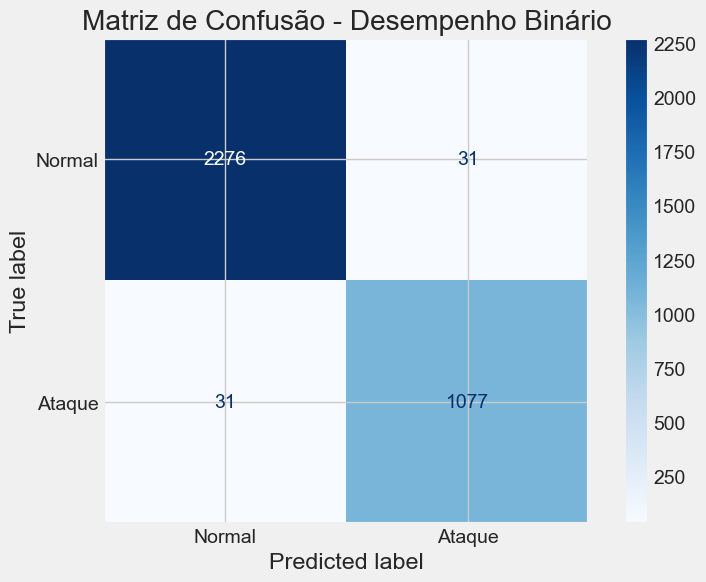

In [4]:
# Convertendo os resultados multiclasse para binário
# 0 para 'Normal', 1 para qualquer tipo de ataque
y_test_binary = np.where(y_test == 'Normal', 0, 1)
y_pred_binary = np.where(y_pred == 'Normal', 0, 1)

print("--- Relatório de Classificação Binária (Normal vs. Ataque) ---")
print(classification_report(y_test_binary, y_pred_binary, target_names=['Normal (0)', 'Ataque (1)']))

# Gerando e plotando a Matriz de Confusão Binária
cm = confusion_matrix(y_test_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Ataque'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusão - Desempenho Binário')
plt.savefig('confusion_matrix_multi_rf.png') # Salva a matriz como imagem
plt.show()

--- Relatório de Classificação por Tipo de Ataque ---
                precision    recall  f1-score   support

        Normal       0.99      0.99      0.99      2307
Reconnaissance       0.99      1.00      1.00       360
       Fuzzers       0.91      0.92      0.92       332
      Analysis       0.90      0.89      0.89       416

      accuracy                           0.97      3415
     macro avg       0.95      0.95      0.95      3415
  weighted avg       0.97      0.97      0.97      3415



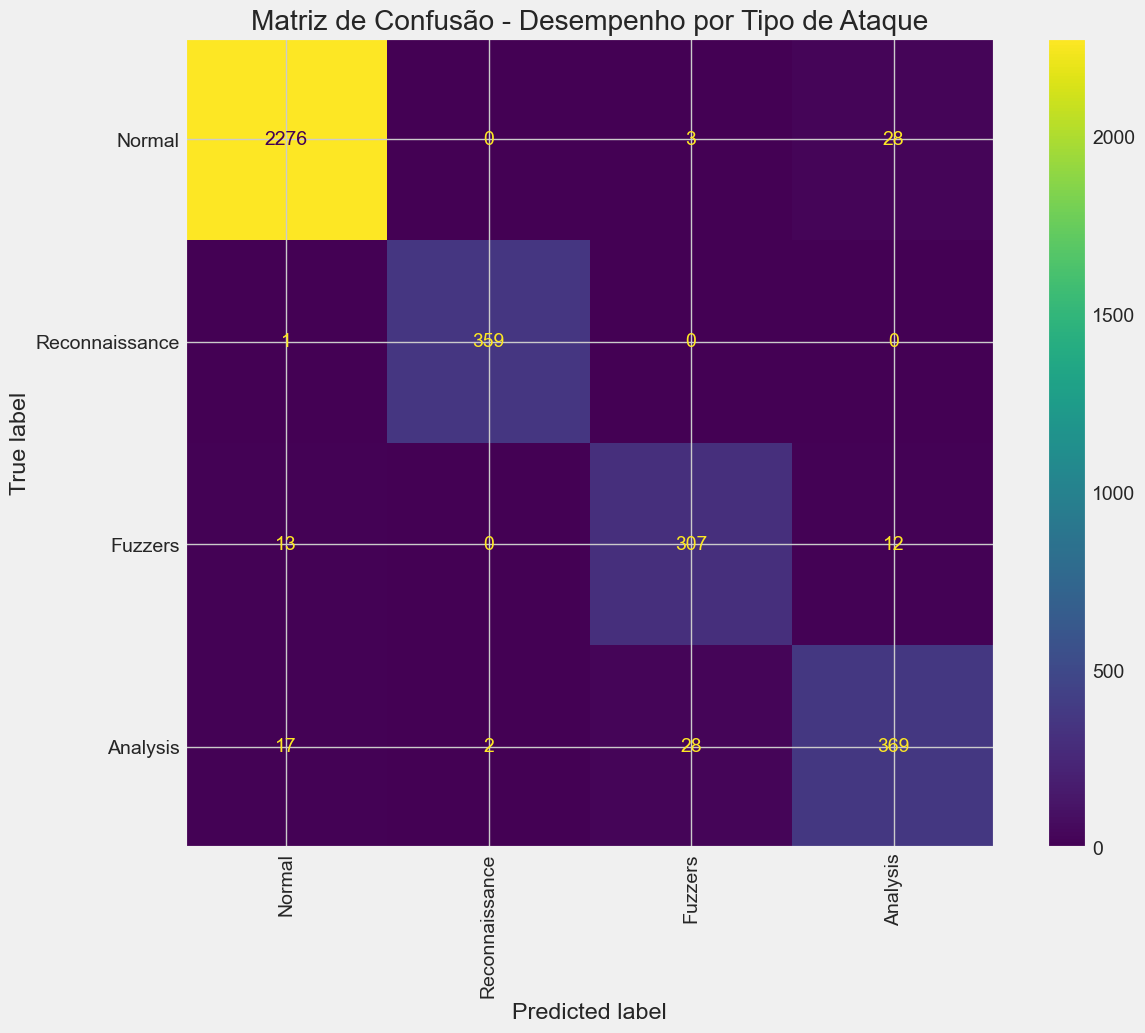

In [5]:
# Obtendo os nomes das classes na ordem correta
class_names = df_train['attack_cat'].unique()

print("--- Relatório de Classificação por Tipo de Ataque ---")
# Usando os rótulos originais multiclasse
print(classification_report(y_test, y_pred, labels=class_names))

# Matriz de Confusão Multiclasse (pode ser grande)
cm_multi = confusion_matrix(y_test, y_pred, labels=class_names)
disp_multi = ConfusionMatrixDisplay(confusion_matrix=cm_multi, display_labels=class_names)

fig, ax = plt.subplots(figsize=(12, 10))
disp_multi.plot(ax=ax, cmap='viridis', xticks_rotation='vertical')
plt.title('Matriz de Confusão - Desempenho por Tipo de Ataque')
plt.savefig('confusion_matrix_atks_multi_rf.png') # Salva a matriz como imagem
plt.show()